## Instance Segmentation

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!rm -rf "./train.zip"
!rm -rf "./validation.zip"
!rm -rf "../data"

!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/train.zip"
!wget "https://s3-us-west-1.amazonaws.com/udacity-robotics/Deep+Learning+Data/Lab/validation.zip"

!mkdir -p "../data/train"
#!mkdir -p "../data/validation"

!unzip "train.zip" -d "../data"
!unzip "validation.zip" -d "../data"

!mv "../data/train_combined/images/" "../data/train/"
!mv "../data/train_combined/masks/" "../data/train/"
!rm -rf "../data/train_combined/"

Streaming output truncated to the last 5000 lines.
  inflating: ../data/train_combined/masks/4_run2_mask_00072.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00073.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00076.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00077.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00078.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00079.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00080.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00081.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00082.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00083.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00084.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00085.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00086.png  
  inflating: ../data/train_combined/masks/4_run2_mask_00089.png  
  inflating: ../data/trai

## Data Loading

In [2]:
import glob
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

In [3]:
train_dir = "../data/train"
valid_dir = "../data/validation"

In [58]:
sorted(glob.glob(train_dir+"/images/*.jpeg"))

['../data/train/images/0_run6_cam1_00000_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00005_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00007_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00008_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00011_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00013_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00016_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00017_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00024_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00025_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00035_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00039_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00041_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00042_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00043_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00047_data_pack2.jpeg',
 '../data/train/images/0_run6_cam1_00050_data_pack2.jpeg

In [59]:
sorted(glob.glob(train_dir+"/masks/*.png"))

['../data/train/masks/0_run6_mask_00000_data_pack2.png',
 '../data/train/masks/0_run6_mask_00005_data_pack2.png',
 '../data/train/masks/0_run6_mask_00007_data_pack2.png',
 '../data/train/masks/0_run6_mask_00008_data_pack2.png',
 '../data/train/masks/0_run6_mask_00011_data_pack2.png',
 '../data/train/masks/0_run6_mask_00013_data_pack2.png',
 '../data/train/masks/0_run6_mask_00016_data_pack2.png',
 '../data/train/masks/0_run6_mask_00017_data_pack2.png',
 '../data/train/masks/0_run6_mask_00024_data_pack2.png',
 '../data/train/masks/0_run6_mask_00025_data_pack2.png',
 '../data/train/masks/0_run6_mask_00035_data_pack2.png',
 '../data/train/masks/0_run6_mask_00039_data_pack2.png',
 '../data/train/masks/0_run6_mask_00041_data_pack2.png',
 '../data/train/masks/0_run6_mask_00042_data_pack2.png',
 '../data/train/masks/0_run6_mask_00043_data_pack2.png',
 '../data/train/masks/0_run6_mask_00047_data_pack2.png',
 '../data/train/masks/0_run6_mask_00050_data_pack2.png',
 '../data/train/masks/0_run6_ma

In [60]:
train_images_paths, train_masks_paths = shuffle(sorted(glob.glob(train_dir+"/images/*.jpeg")), sorted(glob.glob(train_dir+"/masks/*.png")), random_state=42)
#train_masks_paths = glob.glob(train_dir+"/masks/*.png")

valid_images_paths, valid_masks_paths = shuffle(glob.glob(valid_dir+"/images/*.jpeg"), glob.glob(valid_dir+"/masks/*.png"), random_state=42)

assert len(train_images_paths) == len(train_masks_paths)
assert len(valid_images_paths) == len(valid_masks_paths)

In [61]:
print(train_images_paths)

['../data/train/images/4_run2cam1_00610.jpeg', '../data/train/images/1_run1_cam1_04013_data_pack2.jpeg', '../data/train/images/4_run2cam1_00696.jpeg', '../data/train/images/4_run2cam1_00435.jpeg', '../data/train/images/1_run1_cam1_03499_data_pack2.jpeg', '../data/train/images/8_run5cam1_00545.jpeg', '../data/train/images/4_run2cam1_00382.jpeg', '../data/train/images/1_run1_cam1_00633_data_pack2.jpeg', '../data/train/images/1_run1_cam1_02625_data_pack2.jpeg', '../data/train/images/6_run1cam1_00719.jpeg', '../data/train/images/1_run1_cam1_00630_data_pack2.jpeg', '../data/train/images/6_run1cam1_00437.jpeg', '../data/train/images/1_run1_cam1_03960_data_pack2.jpeg', '../data/train/images/1_run1_cam1_02536_data_pack2.jpeg', '../data/train/images/6_run1cam1_01149.jpeg', '../data/train/images/1_run1_cam1_03051_data_pack2.jpeg', '../data/train/images/7_run7cam1_00286.jpeg', '../data/train/images/7_run7cam1_00707.jpeg', '../data/train/images/7_run7cam1_00518.jpeg', '../data/train/images/1_run1_

In [62]:
print(valid_masks_paths)

['../data/validation/masks/4_run2_mask_00334.png', '../data/validation/masks/7_run7_mask_00487.png', '../data/validation/masks/8_run5_mask_00079.png', '../data/validation/masks/9_run3_mask_00023.png', '../data/validation/masks/4_run2_mask_00012.png', '../data/validation/masks/7_run7_mask_00494.png', '../data/validation/masks/4_run2_mask_00460.png', '../data/validation/masks/9_run3_mask_00105.png', '../data/validation/masks/6_run1_mask_00196.png', '../data/validation/masks/7_run7_mask_00294.png', '../data/validation/masks/9_run3_mask_00315.png', '../data/validation/masks/4_run2_mask_00412.png', '../data/validation/masks/4_run2_mask_00100.png', '../data/validation/masks/6_run1_mask_00618.png', '../data/validation/masks/9_run3_mask_00572.png', '../data/validation/masks/7_run7_mask_00693.png', '../data/validation/masks/7_run7_mask_00484.png', '../data/validation/masks/4_run2_mask_00470.png', '../data/validation/masks/4_run2_mask_00017.png', '../data/validation/masks/7_run7_mask_00673.png',

In [63]:
print(f"Total train images is {len(train_images_paths)}")
print(f"Total validation images is {len(valid_images_paths)}")

Total train images is 4131
Total validation images is 1184


In [64]:
def load_images(path_list):
    loaded_images = []
    for path in path_list:
        loaded_images.append(cv2.imread(path))
    return np.array(loaded_images)

train_images = load_images(train_images_paths)
train_masks = load_images(train_masks_paths)
valid_images = load_images(valid_images_paths)
valid_masks = load_images(valid_masks_paths)

In [65]:
print(f"Train images shape is {train_images.shape}")
print(f"Train masks shape is {train_masks.shape}")
print(f"Valid images shape is {valid_images.shape}")
print(f"Valid masks shape is {valid_masks.shape}")

Train images shape is (4131, 256, 256, 3)
Train masks shape is (4131, 256, 256, 3)
Valid images shape is (1184, 256, 256, 3)
Valid masks shape is (1184, 256, 256, 3)


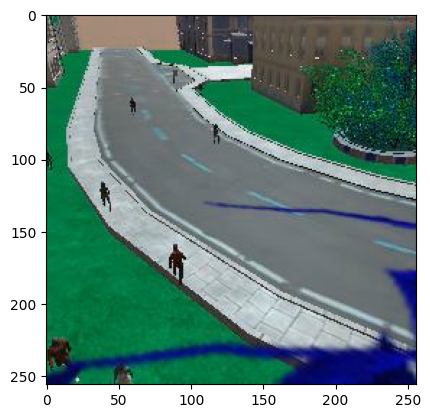

In [66]:
# Visual representation of data
plt.imshow(train_images[0])

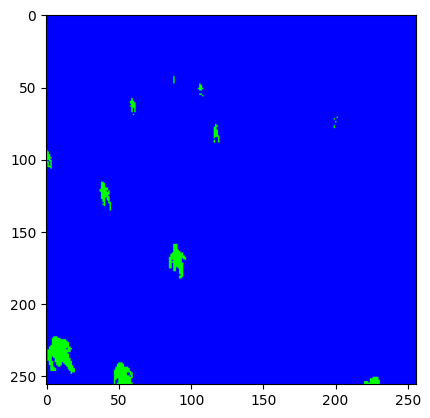

In [67]:
plt.imshow(train_masks[0])

In [68]:
#print(train_masks[1][10:11])
# From here I can see how the segmentation is done on this dataset in that:
# red is the person of interest [255, 0, 0]
# blue is the uninterested region [0, 0, 255]
# green is the people class [0, 255, 0]

In [69]:
def preprocess(images):
    return images/255.0

In [ ]:
train_masks = np.array(train_masks/255.0, dtype=np.int8)#preprocess(train_masks)
valid_images = np.array(valid_masks/255.0, dtype=np.int8)#preprocess(valid_masks)

In [ ]:
#train_images = train_images/255.0

In [ ]:
#valid_images = valid_images/255.0

In [ ]:
batch_size = 8

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_images, train_masks))
    .shuffle(1000)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
    .repeat()
)
train_images=0

valid_ds = (
    tf.data.Dataset.from_tensor_slices((valid_images, valid_masks))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)
valid_images = 0

## Defining model

In [27]:
from keras.models import Model
from keras.layers import Conv2D, Rescaling, Input, UpSampling2D, Concatenate, GlobalAveragePooling2D, UpSampling2D, Reshape, BatchNormalization, Activation
from keras.applications import ResNet50, MobileNetV2

In [28]:
input_shape = (256, 256, 3)
trainable = False
def conv_block(inputs, filters, dilation_rate=1, kernel_size=3, stride=1):
    #print("work_conv")
    x = Conv2D(filters, kernel_size, (stride, stride), padding="same", use_bias=False, dilation_rate=(dilation_rate, dilation_rate))(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    #print("End_conv")
    return x

In [29]:
def base_model(inputs, input_shape=(256, 256, 3), trainable=False):
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
        input_tensor=inputs
    )
    base.trainable = trainable
    return base

In [30]:
def ASPP(input_tensor):
    shape = input_tensor.shape
    #print("Start")
    layer1 = conv_block(input_tensor, 256, 1, 1, 1)
    #print("2")
    layer2 = conv_block(input_tensor, 256, 6, 3, 1)
    #print("3")
    layer3 = conv_block(input_tensor, 256, 12, 3, 1)
    #print("4")
    layer4 = conv_block(input_tensor, 256, 18, 3, 1)
    #print("5")
    layer5 = GlobalAveragePooling2D()(input_tensor)
    layer5 = Reshape((1, 1, layer5.shape[-1]))(layer5)
    layer5 = conv_block(layer5, 256, kernel_size=1)
    layer5 = UpSampling2D(
        size=(shape[1], shape[2]), interpolation="bilinear")(layer5)
    layers_add = Concatenate()([layer1, layer2, layer3, layer4, layer5])
    output = conv_block(layers_add, 256, 1, 1, 1)
    #print("End")
    return output

In [31]:
def encoder(base):
    layers = [
        "conv2_block3_out",
        "conv4_block6_out"
    ]
    layers = [base.get_layer(name).output for name in layers]
    #model_input = base_model(input_tensor, input_shape=input_shape, trainable)
    #model_ouput = ASPP(model_input)
    #encoder_model = Model(model_input, model_output)
    model = Model(base.input, layers)
    return model

In [32]:
def decoder(base_input, ASPP_input):
    #print("Start Decoder")
    layer1 = UpSampling2D(size=(4, 4), interpolation="bilinear")(ASPP_input)
    layer_add = Concatenate()([base_input, layer1])
    layer3 = conv_block(layer_add, 256, 1, 3, 1)
    output = UpSampling2D(size=(4, 4), interpolation="bilinear")(layer3)
    #print("End Decoder")
    return output

In [37]:
def deeplabv3plus(num_classes=3):
    inputs = Input(shape=input_shape)
    rescaled=Rescaling(scale=1./255)(inputs)
    base = base_model(rescaled, input_shape=input_shape, trainable=trainable)
    encoder_output = encoder(base)
    low_level, base_output = encoder_output.output
    aspp_out = ASPP(base_output)
    #print("End encoder")

    low_level = conv_block(low_level, 48, 1, 1, 1)
    decoder_out = decoder(low_level, aspp_out)
    output = Conv2D(num_classes, 1, padding="same")(decoder_out)
    model = Model(inputs=inputs, outputs=output)
    return model

In [38]:
model = deeplabv3plus()

## Training and Testing

In [39]:
learning_rate = 1e-5
batch_size=4
epochs = 40

In [49]:
# Dice Loss and cross entropy loss
def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    d_loss = (2 * intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(d_loss)

cross_entropy_loss = tf.keras.losses.BinaryCrossentropy()


def total_loss(y_true, y_pred):
  return dice_loss(y_true, y_pred) + cross_entropy_loss(y_true, y_pred)

In [50]:
# meen IoU
def meanIoU():
    return mIoU

In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=total_loss,
    metrics=["accuracy"]
)

In [52]:
#model.fit(
#    train_images, train_masks,
#    batch_size=batch_size,
#    epochs=epochs,
#)
model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs,
)

Epoch 1/40
    429/Unknown 107s 180ms/step - accuracy: 0.2839 - loss: 3.7580

KeyboardInterrupt: 